In [ ]:
#Autoreload so we don't have to restart kernel every time we change source code
%load_ext autoreload
%autoreload 2

In [55]:
import os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#%matplotlib qt

#Astronomy
import healpy as hp
import astropy.units as u
from astropy.coordinates import SkyCoord

#My packages

import loader
from constants import data_dir, plt_dir
from constants import SLOPE, OFFSET

# Load data #


In [4]:
data_dir = 'C:/Users/lilyz/BK_dustmaps_dev/data'
beta_intensity = hp.read_map(os.path.join(data_dir, 'COM_CompMap_ThermalDust-commander_2048_R2.00.fits'), field=7, nest=True)
beta_polarization = hp.read_map(os.path.join(data_dir, 'COM_CompMap_QU-thermaldust-commander_2048_R3.00_full.fits'), field=2, nest=True)

In [3]:
"""Initialize objects that represent the CMB and Galactic fields."""
cmb = loader.Field('CMB', data_dir)
gal = loader.Field('GAL', data_dir)

In [45]:
def plot_beta_full(beta_map, title, vmin, vmax, cmb_contour = False, gal_contour = False, save = False, fname = None):
    """Plot full-sky spectral index map in Galactic coordinates."""
    hp.mollview(beta_map,
                coord = ['G'],
                rot = [0, 0, 0],
                nest = True,
                title = title,
                cmap = 'viridis',
                badcolor = 'white',
                min = vmin, max = vmax,
                cbar = False,
                notext = True,
                hold = True)

    # Graticule
    hp.graticule(dpar = 10, dmer = 20)
    # Axes
    ax = plt.gca()
    ax.text(0.0, -1 - 0.06, "Galactic longitude [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-2 - 0.2, 0.0, "Galactic latitude [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$\\beta $", fontsize=10, labelpad=10)
    # Contour
    proj = plt.gca().proj
    if cmb_contour:
        xgrid, ygrid = cmb.get_mesh(galactic = True)
        x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
        x_contour = x_contour.reshape(xgrid.shape)
        y_contour = y_contour.reshape(ygrid.shape)
        ax.contour(x_contour, y_contour, cmb.Pw, levels = [0.001], colors = 'black')

    if gal_contour:
        xgrid, ygrid = gal.get_mesh(galactic = True)
        x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
        x_contour = x_contour.reshape(xgrid.shape)
        y_contour = y_contour.reshape(ygrid.shape)
        ax.contour(x_contour, y_contour, gal.Pw, levels = [0.001], colors = 'black')

    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

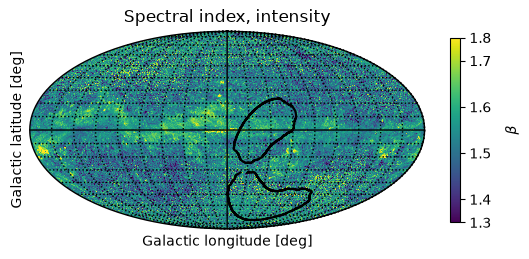

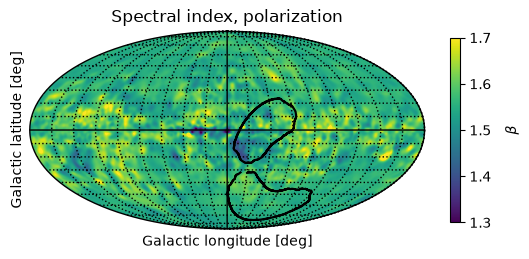

In [47]:
plot_beta_full(beta_intensity, vmin = 1.35, vmax = 1.75, cmb_contour = True, gal_contour = True, title = "Spectral index, intensity")
plot_beta_full(beta_polarization, vmin = 1.3, vmax = 1.7, cmb_contour = True, gal_contour = True, title = "Spectral index, polarization")

In [ ]:
def plot_beta_cmb(beta_map, vmin, vmax, title, save = False, fname = None):
    """Plot integrated extinction in the CMB field."""
    ra_min, ra_max, dec_min, dec_max = cmb.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(beta_map,
                coord = ['G', 'C'],
                rot = [ra_center, dec_center, 0],
                nest = True,
                half_sky = True,
                title = title,
                cmap = 'viridis',
                badcolor = 'white',
                min = vmin, max = vmax,
                cbar = False,
                notext = True,
                hold = True)
    # Graticule
    hp.graticule(dpar = 10, dmer = 25)

    lon_labels = [50, 25, 0, -25]
    lat_labels = [-70, -60, -50]
    lon0 = 50
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat = True, fontsize = 6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat = True, fontsize = 6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-0.6 - 0.1, 0.0, "Declination [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)
    #cbar.set_ticks(np.linspace(0, 1.6, 5))
    cbar.set_label("$\\beta $", fontsize=10, labelpad=10)
    # Contour
    xgrid, ygrid = cmb.get_mesh(galactic = False)
    proj = ax.proj
    x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
    x_contour = x_contour.reshape(xgrid.shape)
    y_contour = y_contour.reshape(ygrid.shape)

    ax.contour(x_contour, y_contour, cmb.Pw, levels = [0.001], colors = 'black')
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

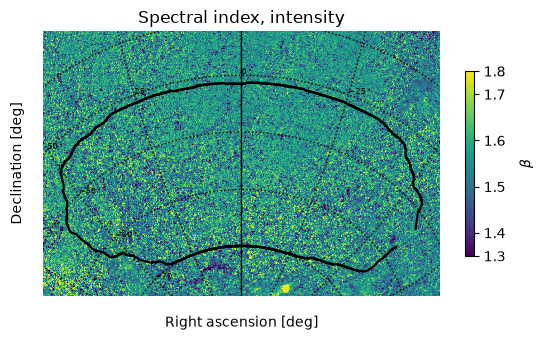

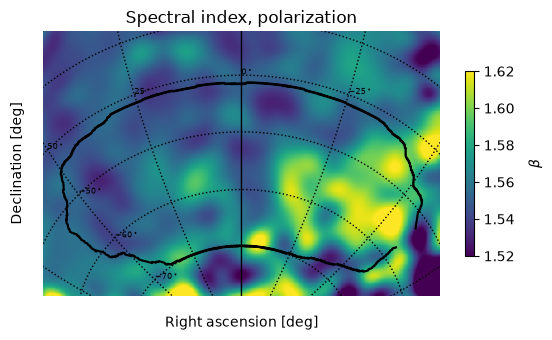

In [34]:
plot_beta_cmb(beta_intensity, vmin = 1.35, vmax = 1.75, title = "Spectral index, intensity")
plot_beta_cmb(beta_polarization, vmin = 1.52, vmax = 1.62, title = "Spectral index, polarization")

In [37]:
def plot_beta_gal(beta_map, vmin, vmax, title, save = False, fname = None):
    """Plot integrated extinction in the CMB field."""
    ra_min, ra_max, dec_min, dec_max = gal.get_bbox()
    ra_center = (ra_min + ra_max) / 2
    dec_center = (dec_min + dec_max) / 2
    hp.orthview(beta_map,
                coord = ['G', 'C'],
                rot = [ra_center, dec_center, 0],
                nest = True,
                half_sky = True,
                title = title,
                cmap = 'viridis',
                badcolor = 'white',
                min = vmin, max = vmax,
                cbar = False,
                notext = True,
                hold = True)
    # Graticule
    hp.graticule(dpar = 10, dmer = 25)

    lon_labels = [260, 235, 210]
    lat_labels = [-40, -50, -60, -70]
    lon0 = 285
    lat0 = -40
    for lon in lon_labels:
        hp.projtext(lon, lat0, f"${lon}^\\circ$", lonlat = True, fontsize = 6)
    for lat in lat_labels:
        hp.projtext(lon0, lat, f"${lat}^\\circ$", lonlat = True, fontsize = 6)

    # Axes
    ax = plt.gca()
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(-0.4, 0.4)
    ax.text(0.0, -0.4 - 0.06, "Right ascension [deg]", fontsize=10, va='top', ha='center', color='black')
    ax.text(-0.6 - 0.1, 0.0, "Declination [deg]", fontsize=10, rotation=90, va='center', ha='left', color='black')
    # Colorbar
    im = ax.get_images()[0]
    cbar = plt.colorbar(im, ax=ax, shrink = 0.5)

    cbar.set_label("$\\beta $", fontsize=10, labelpad=10)
    # Contour
    xgrid, ygrid = gal.get_mesh(galactic = False)    
    proj = ax.proj
    x_contour, y_contour = proj.ang2xy(xgrid.ravel(), ygrid.ravel(), lonlat=True)
    x_contour = x_contour.reshape(xgrid.shape)
    y_contour = y_contour.reshape(ygrid.shape)
    ax.contour(x_contour, y_contour, gal.Pw, levels = [0.001], colors = 'black')
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches='tight')
        plt.close()
    else:
        plt.show()           

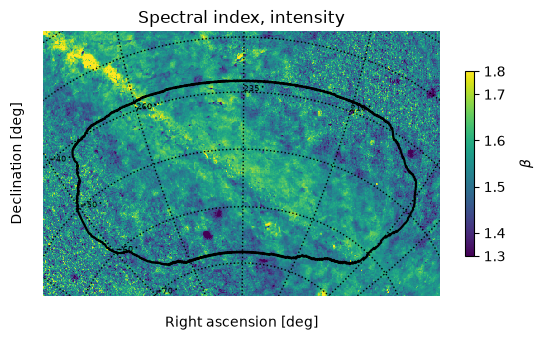

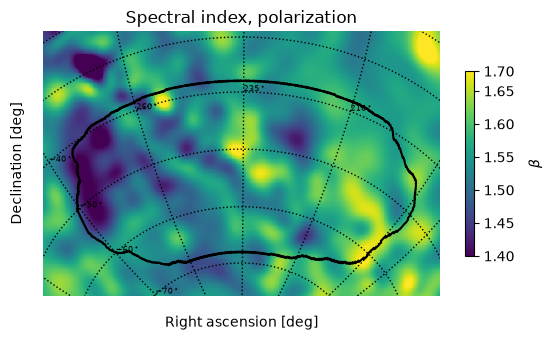

In [38]:
plot_beta_gal(beta_intensity, vmin = 1.35, vmax = 1.75, title = "Spectral index, intensity")
plot_beta_gal(beta_polarization, vmin = 1.4, vmax = 1.68, title = "Spectral index, polarization")

# Beta vs. R(V) correlation #

In [50]:
ZhangGreen = loader.HDF5Loader(data_dir, 'Rv_map_new.h5')
RV_map_int_256 = ZhangGreen.load_data(['map_256/R55_map_int']) * SLOPE + OFFSET

Loading ['map_256/R55_map_int'] from disk into RAM (this happens only once)...


In [51]:
#Collates a (M, N) array into a length N array by taking the furthest non-NaN value along the first axis.
def collate(raw_data : np.ndarray) -> np.ndarray:
    if(raw_data.ndim != 2):
       print("Invalid array dimensions (must be 2)")
    else:
        mask = ~np.isnan(raw_data)
        row_indices = np.where(mask.any(axis=0), mask.shape[0] - 1 - np.argmax(mask[::-1, :], axis=0), -1)
        data = np.full(raw_data.shape[1], np.nan)
        valid_pixels = row_indices != -1
        data[valid_pixels] = raw_data[row_indices[valid_pixels], np.arange(raw_data.shape[1])[valid_pixels]]
    return data

In [52]:
"""Collate the integrated R(V) map: each pixel takes its furthest available measurement."""
RV_map_256 = collate(RV_map_int_256)

In [65]:
def plot_rv_beta_heatmap(beta_map, field, title, bins = 100, hist_range = None,
                         vmin = None, vmax = None, save = False, fname = None):
    """Plot a 2D histogram of R(V) against spectral index over a field's bounding box."""
    # Degrade the beta map to the resolution of the collated R(V) map
    nside = hp.npix2nside(len(RV_map_256))
    beta_low_res = hp.ud_grade(beta_map, nside_out = nside, order_in = 'NEST')

    # Celestial coordinates of every pixel
    l, b = hp.pix2ang(nside, np.arange(hp.nside2npix(nside)), nest = True, lonlat = True)
    coords = SkyCoord(l = l * u.deg, b = b * u.deg, frame = 'galactic').transform_to('fk5')
    ra_all = coords.ra.deg
    dec_all = coords.dec.deg

    # Cut to the field's bounding box
    ra_min, ra_max, dec_min, dec_max = field.get_bbox()
    if ra_min < 0:
        # The CMB field straddles RA = 0, so its bounding box is given in [-180, 180]
        ra_all = np.where(ra_all > 180, ra_all - 360, ra_all)
    field_mask = (
        (ra_all >= ra_min) & (ra_all <= ra_max) &
        (dec_all >= dec_min) & (dec_all <= dec_max)
    )
    rv_field = RV_map_256[field_mask]
    beta_field = beta_low_res[field_mask]

    # Clean out any NaN or infinite values
    valid_mask = np.isfinite(rv_field) & np.isfinite(beta_field)
    rv_plot = rv_field[valid_mask]
    beta_plot = beta_field[valid_mask]

    fig = plt.figure(figsize = (5, 5))
    ax = fig.add_subplot()
    hist, rv_edges, beta_edges = np.histogram2d(rv_plot, beta_plot, bins = bins, range = hist_range)
    width, height = hist.shape
    extent = [0, width, 0, height]
    im = plt.imshow(hist, cmap = 'viridis', origin = 'lower', vmin = vmin, vmax = vmax, extent = extent)
    xlabnums = [1.3, 1.4, 1.5, 1.6, 1.7, 1.8]
    ylabnums = [2, 3, 4, 5, 6, 7, 8]    
    xstep = (xlabnums[1] - xlabnums[0]) / (xlabnums[-1] - xlabnums[0])
    ystep = (ylabnums[1] - ylabnums[0]) / (ylabnums[-1] - ylabnums[0])
    xticks = np.arange(0, hist.shape[1] + 1, xstep * hist.shape[1])
    yticks = np.arange(0, hist.shape[0] + 1, ystep * hist.shape[0])
    ax.set_xticks(xticks, labels = xlabnums)
    ax.set_yticks(yticks, labels = ylabnums)
    # Formatting
    ax.set_xlabel(r'$\beta$')
    ax.set_ylabel(r'$R(V)$')
    ax.set_title(title + f'\nRA ({ra_max:.0f}, {ra_min:.0f}) Dec ({dec_min:.0f}, {dec_max:.0f})')
    ax.grid(True, alpha = 0.5, linestyle = '--')
    cbar = fig.colorbar(im, ax = ax, orientation = 'vertical', shrink = 0.7, label = "counts")
    # Save or show
    if save:
        plt.savefig(os.path.join(plt_dir, fname), bbox_inches = 'tight')
        plt.close()
    else:
        plt.show()

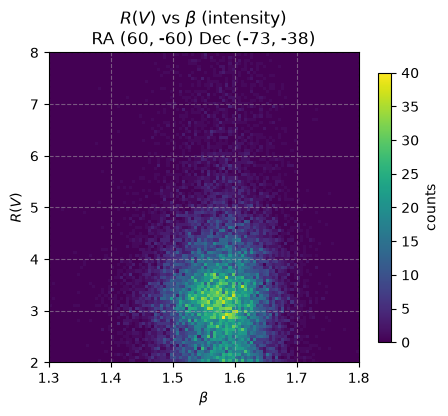

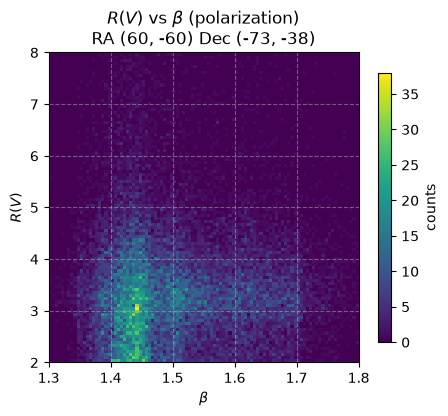

In [62]:
plot_rv_beta_heatmap(beta_intensity, cmb, bins = 100, title = r'$R(V)$ vs $\beta$ (intensity)')
plot_rv_beta_heatmap(beta_polarization, cmb, bins = 100, title = r'$R(V)$ vs $\beta$ (polarization)')

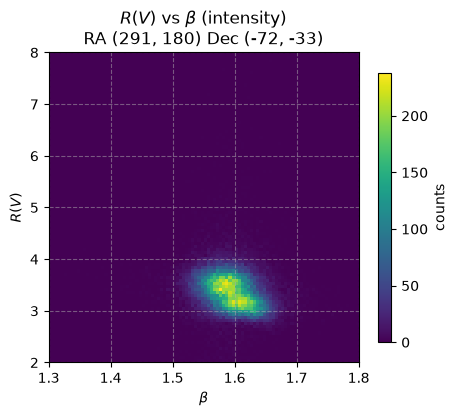

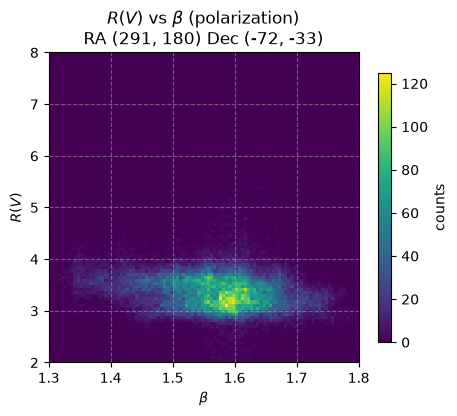

In [63]:
plot_rv_beta_heatmap(beta_intensity, gal, bins = 100, title = r'$R(V)$ vs $\beta$ (intensity)')
plot_rv_beta_heatmap(beta_polarization, gal, bins = 100, title = r'$R(V)$ vs $\beta$ (polarization)')